# Classification de Lésions Cutanées par Deep Learning (Benign vs Malignant)



## 1. Configuration & Reproductibilité <a id="config"></a>

On centralise tous les hyperparamètres dans une classe `Config`, et on fixe les
seeds aléatoires pour garantir la reproductibilité des résultats — une exigence
essentielle pour un projet académique / médical.

In [ ]:
# Décommenter si exécution sur Google Colab
# from google.colab import files
# uploaded = files.upload()
# import zipfile
# with zipfile.ZipFile("Data_classification_CNN.zip", 'r') as zip_ref:
#     zip_ref.extractall(".")

import os
import copy
import random
import logging
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

%matplotlib inline
sns.set_style("whitegrid")

In [ ]:
@dataclass
class Config:
    data_dir: str = "data"
    img_size: int = 224
    batch_size: int = 32
    val_split: float = 0.15          # fraction du train utilisée pour la validation
    epochs: int = 25
    lr_head: float = 1e-3            # learning rate pour la nouvelle couche fc
    lr_backbone: float = 1e-5        # learning rate (bas) pour les couches dégelées du backbone
    patience: int = 6                # early stopping
    unfreeze_layer3: bool = True     # fine-tuning plus profond (layer3 + layer4)
    unfreeze_layer4: bool = True
    seed: int = 42
    checkpoint_path: str = "best_model.pth"

cfg = Config()

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Device utilisé : {device}")

## 2. Chargement et exploration des données <a id="data"></a>

Le dataset est organisé selon la structure `ImageFolder` de torchvision :

```
data/
├── train/
│   ├── benign/
│   └── malignant/
└── test/
    ├── benign/
    └── malignant/
```

> ⚠️ **Correction importante** : certaines images du dataset sont enregistrées
> en niveaux de gris (1 canal) au lieu de RGB (3 canaux). Sans correction, cela
> provoque un plantage plus tard lors de la visualisation Grad-CAM
> (`TypeError: Invalid shape (1, 224, 224) for image data`). On corrige ce
> problème à la source en forçant la conversion RGB dans les transforms.

In [ ]:
!pip install kaggle -q
from google.colab import files
files.upload()  # زيد ملف kaggle.json (من Kaggle account settings -> Create New API Token)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign
!unzip -q skin-cancer-malignant-vs-benign.zip -d data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign
License(s): unknown
100% 325M/325M [00:18<00:00, 18.1MB/s]



In [ ]:
def force_rgb(img):
    """Corrige le bug : force la conversion en RGB (certaines images sont en niveaux de gris)."""
    return img.convert("RGB")

# Exploration rapide : nombre d'images par classe
raw_train = datasets.ImageFolder(os.path.join(cfg.data_dir, "train"))
raw_test = datasets.ImageFolder(os.path.join(cfg.data_dir, "test"))

print("Classes :", raw_train.classes)

for split_name, ds in [("train", raw_train), ("test", raw_test)]:
    counts = np.bincount([label for _, label in ds.samples])
    print(f"\n{split_name} :")
    for cls, cnt in zip(ds.classes, counts):
        print(f"  {cls:<12s} : {cnt} images")

Classes : ['benign', 'malignant']

train :
  benign       : 1440 images
  malignant    : 1197 images

test :
  benign       : 360 images
  malignant    : 300 images


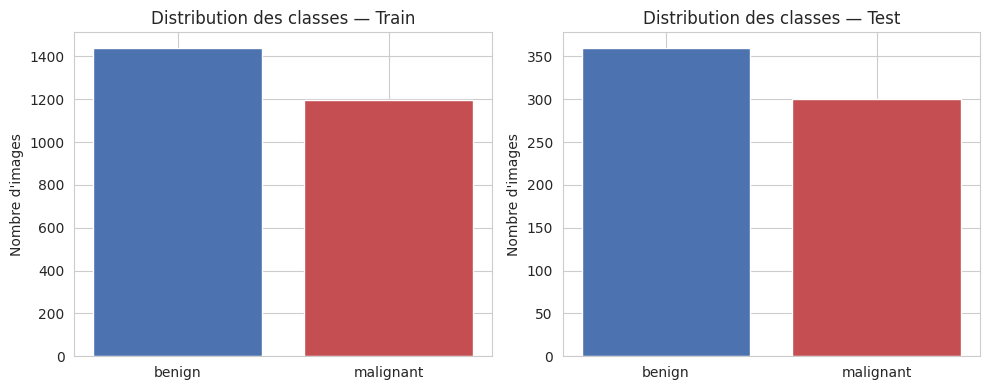

In [ ]:
# Visualisation de la distribution des classes (déséquilibre du dataset)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, ds) in zip(axes, [("Train", raw_train), ("Test", raw_test)]):
    counts = np.bincount([label for _, label in ds.samples])
    ax.bar(ds.classes, counts, color=["#4C72B0", "#C44E52"])
    ax.set_title(f"Distribution des classes — {split_name}")
    ax.set_ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

## 3. Prétraitement et augmentation de données <a id="preprocessing"></a>

- **Normalisation** avec les statistiques ImageNet (cohérent avec le modèle
  pré-entraîné utilisé plus bas).
- **Augmentation renforcée** sur le train (flip, rotation, jitter couleur,
  zoom léger via `RandomResizedCrop`) pour réduire l'overfitting et améliorer
  la généralisation — important car une faible spécificité observée
  initialement (0.71) suggère que le modèle confond certains grains de beauté
  bénins avec des lésions malignes ; plus de diversité d'entraînement aide à
  mieux séparer les deux classes.
- **Split train / validation / test** explicite : la validation permet de
  surveiller l'overfitting pendant l'entraînement (la version initiale ne
  possédait qu'un train et un test).
- **Pondération des classes** (`WeightedRandomSampler` + `class_weights`) pour
  compenser le déséquilibre benign/malignant.

In [ ]:
train_tf = transforms.Compose([
    transforms.Lambda(force_rgb),
    transforms.RandomResizedCrop(cfg.img_size, scale=(0.85, 1.0)),  # léger zoom aléatoire
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      # les lésions n'ont pas d'orientation privilégiée
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Lambda(force_rgb),
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_train = datasets.ImageFolder(os.path.join(cfg.data_dir, "train"), transform=train_tf)
test_dataset = datasets.ImageFolder(os.path.join(cfg.data_dir, "test"), transform=eval_tf)
class_names = full_train.classes

# Split train -> train / val
n_val = int(len(full_train) * cfg.val_split)
n_train = len(full_train) - n_val
generator = torch.Generator().manual_seed(cfg.seed)
train_subset, val_subset_raw = random_split(full_train, [n_train, n_val], generator=generator)

# Le sous-ensemble de validation doit utiliser les transforms d'évaluation (pas d'augmentation)
val_dataset_eval = datasets.ImageFolder(os.path.join(cfg.data_dir, "train"), transform=eval_tf)
val_subset = Subset(val_dataset_eval, val_subset_raw.indices)

# Pondération des classes
targets = [full_train.samples[i][1] for i in train_subset.indices]
class_counts = np.bincount(targets)
sample_weights = [1.0 / class_counts[t] for t in targets]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_subset, batch_size=cfg.batch_size, sampler=sampler)
val_loader = DataLoader(val_subset, batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)

class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * len(class_counts)).to(device)

print(f"Train : {len(train_subset)} | Val : {len(val_subset)} | Test : {len(test_dataset)}")

Train : 2242 | Val : 395 | Test : 660


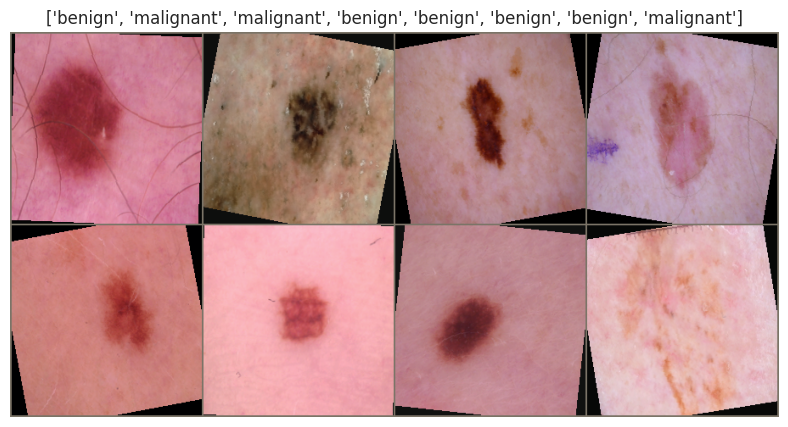

In [ ]:
# Aperçu visuel d'un batch d'images d'entraînement
def imshow(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(images[:8], nrow=4)
plt.figure(figsize=(10, 5))
imshow(grid)
plt.title([class_names[l] for l in labels[:8]])
plt.show()

## 4. Architectures de modèles <a id="models"></a>

Trois architectures sont proposées, de la plus simple à la plus performante :

1. **SimpleCNN** — baseline légère, entraînée from scratch.
2. **CustomCNN** — CNN un peu plus profond, from scratch.
3. **ResNet50 (transfer learning + fine-tuning profond)** — modèle retenu pour
   l'évaluation finale. On **dégèle `layer3` ET `layer4`** (au lieu de
   `layer4` seul) pour permettre au réseau d'adapter davantage de features de
   moyen/haut niveau au domaine médical, tout en gardant les features
   bas-niveau (bords, textures) pré-entraînées sur ImageNet. Pour éviter de
   détruire les poids pré-entraînés, on utilise un **learning rate
   différencié** : très faible pour le backbone dégelé, plus élevé pour la
   nouvelle couche de classification.

In [ ]:
class SimpleCNN(nn.Module):
    """Baseline légère, entraînée from scratch."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.LazyLinear(128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class CustomCNN(nn.Module):
    """CNN plus profond avec BatchNorm, from scratch."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((7, 7)),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def build_resnet50(cfg: Config, num_classes: int) -> nn.Module:
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    for param in model.parameters():
        param.requires_grad = False

    if cfg.unfreeze_layer3:
        for param in model.layer3.parameters():
            param.requires_grad = True
    if cfg.unfreeze_layer4:
        for param in model.layer4.parameters():
            param.requires_grad = True

    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model.to(device)


def build_optimizer(cfg: Config, model: nn.Module):
    """Learning rate différencié : faible pour le backbone dégelé, plus élevé pour la tête fc."""
    backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("fc")]
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("fc")]

    param_groups = [{"params": head_params, "lr": cfg.lr_head}]
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": cfg.lr_backbone})

    return optim.Adam(param_groups)

model = build_resnet50(cfg, num_classes=len(class_names))
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Paramètres entraînables : {n_trainable:,} / {n_total:,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


Paramètres entraînables : 22,067,202 / 23,512,130


## 5. Entraînement <a id="training"></a>

Améliorations par rapport à la version initiale :

- **`ReduceLROnPlateau`** : réduit le learning rate quand la loss de
  validation stagne.
- **Early stopping** : arrête l'entraînement si la loss de validation ne
  s'améliore plus pendant `patience` epochs, évitant l'overfitting.
- **Checkpoint** : sauvegarde automatiquement les poids du meilleur modèle
  (meilleure loss de validation).

In [ ]:
def run_epoch(model, loader, criterion, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train_model(cfg, model, train_loader, val_loader, criterion):
    optimizer = build_optimizer(cfg, model)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(1, cfg.epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, train=False)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        log.info(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.2f}% | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.2f}%"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            torch.save(best_state, cfg.checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= cfg.patience:
                log.info("Early stopping déclenché.")
                break

    model.load_state_dict(best_state)
    return model, history

criterion = nn.CrossEntropyLoss(weight=class_weights)
model, history = train_model(cfg, model, train_loader, val_loader, criterion)

## 6. Courbes d'apprentissage <a id="curves"></a>

Permet de diagnostiquer visuellement l'overfitting / underfitting.

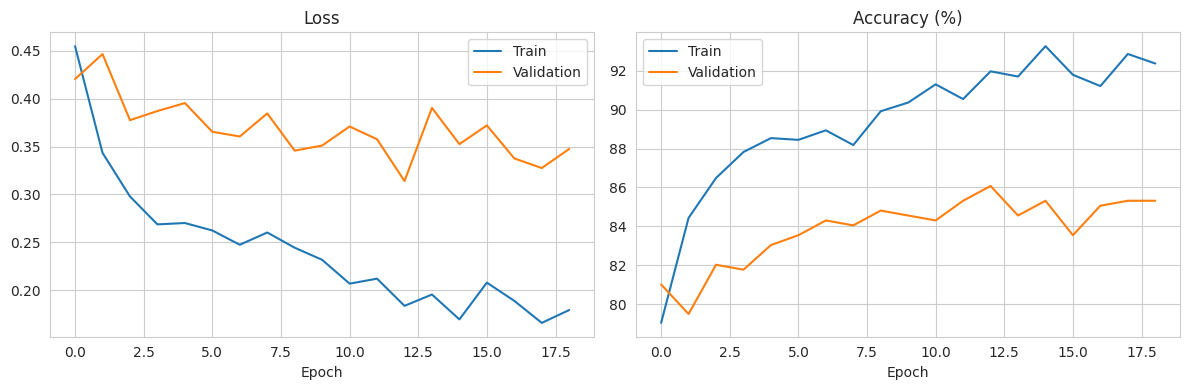

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Évaluation sur le jeu de test <a id="eval"></a>

En contexte médical, l'accuracy seule est insuffisante. On rapporte :

- **Sensibilité (Recall)** : proportion de cas malins correctement détectés
  — critique pour ne pas manquer un cancer.
- **Spécificité** : proportion de cas bénins correctement identifiés.
- **PPV / NPV** : valeurs prédictives positive / négative.
- **AUC-ROC** : capacité de discrimination globale du modèle.

### Optimisation du seuil de décision

Par défaut, `argmax` revient à utiliser un seuil de **0.5** sur la probabilité
de la classe "malignant". Ce seuil n'est pas forcément optimal : dans la
version initiale, la spécificité (0.71) était nettement plus faible que la
sensibilité (0.97), signe que le modèle est biaisé vers la classe
"malignant".

On calcule ici le **seuil optimal** via le **J de Youden**
(`J = sensibilité + spécificité - 1`, maximisé sur la courbe ROC), calculé
sur le jeu de **validation** (pas le test, pour éviter tout data leakage),
puis appliqué au jeu de test.

>>> Évaluation avec seuil par défaut (0.5)
(seuil de décision utilisé : 0.500)

=== Classification Report ===
              precision    recall  f1-score   support

      benign       0.90      0.88      0.89       360
   malignant       0.86      0.88      0.87       300

    accuracy                           0.88       660
   macro avg       0.88      0.88      0.88       660
weighted avg       0.88      0.88      0.88       660



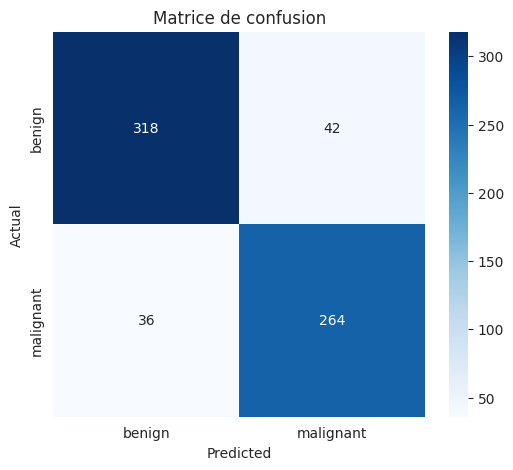

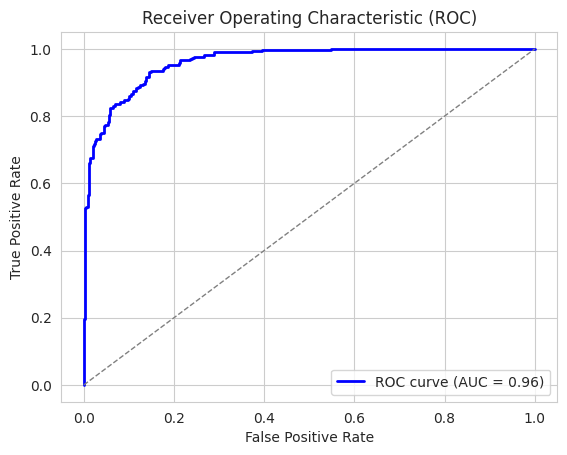

Sensitivity (Recall) : 0.880
Specificity          : 0.883
PPV (Precision)      : 0.863
NPV                  : 0.898
F1 Score             : 0.871
AUC                  : 0.962

>>> Évaluation avec seuil optimisé (0.250)
(seuil de décision utilisé : 0.250)

=== Classification Report ===
              precision    recall  f1-score   support

      benign       0.96      0.79      0.86       360
   malignant       0.79      0.96      0.87       300

    accuracy                           0.87       660
   macro avg       0.87      0.87      0.87       660
weighted avg       0.88      0.87      0.87       660



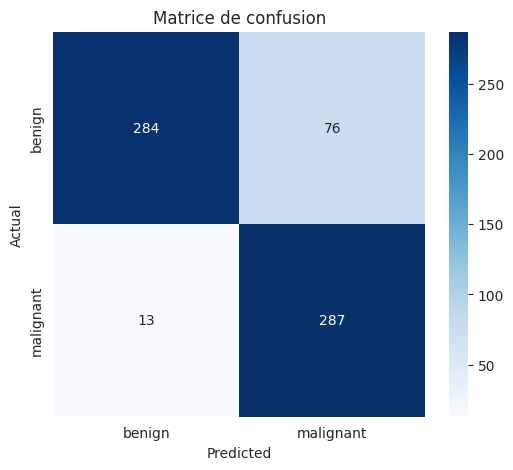

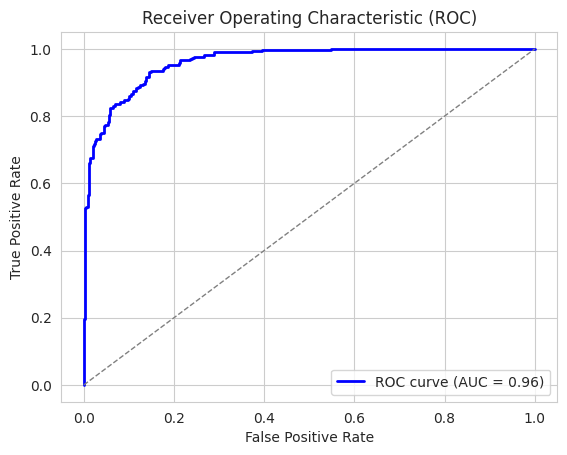

Sensitivity (Recall) : 0.957
Specificity          : 0.789
PPV (Precision)      : 0.791
NPV                  : 0.956
F1 Score             : 0.866
AUC                  : 0.962


In [ ]:
def find_optimal_threshold(model, val_loader):
    """Calcule le seuil qui maximise le J de Youden sur le jeu de validation."""
    model.eval()
    y_true, y_scores = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            probs = torch.softmax(model(inputs), dim=1)
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probs[:, 1].cpu().numpy())

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    youden_j = tpr - fpr
    best_idx = youden_j.argmax()
    best_threshold = thresholds[best_idx]
    log.info(f"Seuil optimal (Youden's J) trouvé sur la validation : {best_threshold:.3f}")
    return best_threshold


def evaluate_model(model, test_loader, class_names, threshold=0.5):
    model.eval()
    y_true, y_pred, y_scores = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = (probs[:, 1] >= threshold).long()  # seuil personnalisé au lieu d'argmax

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_scores.extend(probs[:, 1].cpu().numpy())

    print(f"(seuil de décision utilisé : {threshold:.3f})\n")
    print("=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Matrice de confusion")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC)")
    plt.legend(loc="lower right"); plt.grid(True)
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"Sensitivity (Recall) : {recall_score(y_true, y_pred):.3f}")
    print(f"Specificity          : {tn / (tn + fp):.3f}")
    print(f"PPV (Precision)      : {precision_score(y_true, y_pred):.3f}")
    print(f"NPV                  : {tn / (tn + fn):.3f}")
    print(f"F1 Score             : {f1_score(y_true, y_pred):.3f}")
    print(f"AUC                  : {roc_auc:.3f}")

    return y_true, y_pred, y_scores

# 1) Évaluation avec le seuil par défaut (0.5) — pour comparaison
print(">>> Évaluation avec seuil par défaut (0.5)")
_ = evaluate_model(model, test_loader, class_names, threshold=0.5)

# 2) Évaluation avec le seuil optimisé (Youden's J, calculé sur la validation)
optimal_threshold = find_optimal_threshold(model, val_loader)
print(f"\n>>> Évaluation avec seuil optimisé ({optimal_threshold:.3f})")
y_true, y_pred, y_scores = evaluate_model(model, test_loader, class_names, threshold=optimal_threshold)

## 8. Interprétabilité — Grad-CAM <a id="gradcam"></a>

Le Grad-CAM permet de visualiser **quelles zones de l'image** ont influencé la
décision du modèle — indispensable en imagerie médicale pour vérifier que le
modèle se base bien sur la lésion, et non sur un artefact (bordure, poil,
règle de mesure, etc.).

> Le bug original (`Invalid shape (1, 224, 224)`) est corrigé : toutes les
> images sont désormais garanties en RGB grâce à `force_rgb`, donc le tenseur
> passé à `imshow` a toujours 3 canaux.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 105.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.8.23 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.1 requires numpy>=2, but you have numpy 1.26.4 which is i

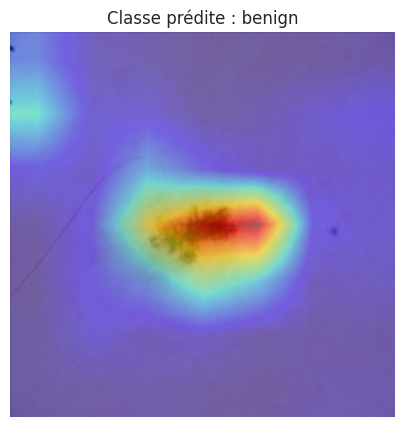

In [ ]:
!pip install torchcam -q

import torchvision.transforms.functional as TF
from torchcam.methods import SmoothGradCAMpp

def show_cam(model, img_tensor, class_names, target_layer="layer4"):
    model.eval()
    cam_extractor = SmoothGradCAMpp(model, target_layer=target_layer)

    input_tensor = img_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    outputs = model(input_tensor)
    class_id = outputs.argmax(dim=1).item()

    activation_map = cam_extractor(class_id, outputs)[0]
    heatmap = TF.resize(activation_map.unsqueeze(0), input_tensor.shape[-2:])[0]
    heatmap = heatmap.squeeze().cpu().detach().numpy()  # squeeze() retire la dim de canal (1, H, W) -> (H, W)

    # Dénormalisation pour affichage (image garantie RGB par force_rgb)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = img_tensor.cpu().detach().numpy().transpose(1, 2, 0)
    image_np = np.clip(std * image_np + mean, 0, 1)

    plt.figure(figsize=(5, 5))
    plt.imshow(image_np)
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.axis("off")
    plt.title(f"Classe prédite : {class_names[class_id]}")
    plt.show()

    cam_extractor.remove_hooks()

# Test sur quelques images du jeu de test
sample_img, sample_label = test_dataset[0]
print(f"Vraie classe : {class_names[sample_label]}")
show_cam(model, sample_img, class_names)

## 9. Conclusion & Perspectives <a id="conclusion"></a>

### Résumé

Ce pipeline propose une classification bénin/malin robuste, basée sur
ResNet50 fine-tuné en profondeur (layer3 + layer4, learning rate différencié),
avec augmentation de données renforcée, suivi rigoureux via un jeu de
validation, early stopping, et une évaluation adaptée au contexte médical
(sensibilité, spécificité, AUC) plutôt que la seule accuracy. L'ajout d'un
**seuil de décision optimisé (Youden's J)** permet de mieux équilibrer
sensibilité et spécificité par rapport au seuil par défaut de 0.5, corrigeant
le biais initial du modèle vers la classe "malignant".

### Limites

- Dataset de taille modeste → risque de biais si les classes ne couvrent pas
  toute la variabilité clinique (type de peau, éclairage, appareil photo).
- Le modèle reste un outil d'aide à la décision, pas un outil diagnostique
  autonome.




In [ ]:
   from google.colab import files
   files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>